<a href="https://colab.research.google.com/github/gerardovazquez-DataAnalyst/connectatel_customer_analysis/blob/main/connectatel_customer_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 ConnectaTel — Análisis de Comportamiento de Usuarios LATAM

**Objetivo:** Analizar el comportamiento de 4,000 usuarios por edad, volumen de uso y plan contratado — distribuciones, outliers, segmentación y oportunidades comerciales.

**Período de actividad cubierto:** Enero–Junio 2024

Regiones: LATAM (Bogotá, CDMX, Medellín, GDL, Cali, MTY)

**Objetivo:** Analizar el comportamiento de clientes de ConnectaTel en Latinoamérica utilizando datos de planes, usuarios y uso de servicios, con el fin de identificar patrones de consumo, detectar anomalías, construir segmentos de clientes y generar oportunidades de retención y optimización de planes.

**Periodo de actividad cubierto:** Datos históricos hasta 2024

**Fuentes de datos:**

* `plans.csv`: Información de planes (precio, minutos, GB incluidos, costos adicionales)
* `users.csv`: Datos de clientes (edad, ciudad, fecha de registro, tipo de plan, churn)
* `usage.csv`: Uso real del servicio (llamadas y mensajes)




**Alcance del análisis:** Exploración, limpieza y análisis de datos (EDA) para construir perfiles estadísticos, identificar comportamientos atípicos y segmentar clientes con base en su uso y características demográficas.

**Región:** LATAM

## 🧩 Análisis exploratorio

Antes de limpiar o transformar cualquier dato, se realizó una exploración inicial de los tres datasets con el objetivo de conocer su estructura, detectar inconsistencias y anticipar problemas de calidad antes de iniciar el análisis.

### 1.1 Carga de datos y vista rápida

Se importaron las librerías necesarias y se cargaron los tres datasets. Se revisaron las primeras filas de cada uno para obtener una primera impresión de su contenido.

In [10]:
#Se cargaron datos previamente a google drive y se otorgó acceso
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
# ── Librerías ────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
print('Librerias cargadas')

Librerias cargadas


In [12]:
# ── Carga de datos ───────────────────────────────────────────────────
ruta = '/content/drive/MyDrive/Proyecto- connectatel_customer_analysis/'
plans = pd.read_csv(ruta + 'plans.csv')
users = pd.read_csv(ruta + 'users_latam.csv')
usage = pd.read_csv(ruta + 'usage.csv')

print('datasets cargados')

datasets cargados


In [13]:
# ── Vista rápida ─────────────────────────────────────────────────────
print('=== PLANES ===')
display(plans.head())

print('=== USUARIOS===')
display(users.head())

print('=== USO ===')
display(usage.head())

=== PLANES ===


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


=== USUARIOS===


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


=== USO ===


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


### 1.2 Exploración de la estructura de los datasets

Se inspeccionaron las dimensiones y tipos de datos de cada dataset para confirmar que la carga fue exitosa y detectar columnas que requerirían transformación.

In [14]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [15]:
# inspección de plans con .info() para tipos de datos y nulos
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 260.0+ bytes


In [50]:
# inspección de users con .info() para tipos de datos y nulos
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     4000 non-null   int64         
 1   first_name  4000 non-null   object        
 2   last_name   4000 non-null   object        
 3   age         4000 non-null   int64         
 4   city        3435 non-null   object        
 5   reg_date    3960 non-null   datetime64[ns]
 6   plan        4000 non-null   object        
 7   churn_date  466 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 250.1+ KB


In [51]:
# inspección de usage con .info() para tipos de datos y nulos
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   id        40000 non-null  int64         
 1   user_id   40000 non-null  int64         
 2   type      40000 non-null  object        
 3   date      39950 non-null  datetime64[ns]
 4   duration  17924 non-null  float64       
 5   length    22104 non-null  float64       
 6   is_text   40000 non-null  int64         
 7   is_call   40000 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(4), object(1)
memory usage: 2.4+ MB


**Nota:** El dataset `plans.csv` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

Se contabilizaron los valores faltantes por columna para `users` y `usage`y se calculó su proporción para evaluar si afectaban el análisis o requerían tratamiento.

Se consideró lo siguiente para tomar una decisión sobre los valores nulos.

- Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.
- Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.
- Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

In [52]:
# cantidad de nulos para users
print("Cantidad de valores nulos para users\n", users.isna().sum())
print()
print("Proporción de valores nulos para user\n", users.isna().mean()*100)

Cantidad de valores nulos para users
 user_id          0
first_name       0
last_name        0
age              0
city           565
reg_date        40
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos para user
 user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          14.125
reg_date       1.000
plan           0.000
churn_date    88.350
dtype: float64


- ¿Qué columnas tienen valores faltantes y en qué proporción?
La columna `city` presenta 11.72% y `churn_date` un 88.35%
- Indica qué harías: ¿imputar, eliminar, ignorar?
    
    La columna `city` se investiga en los siguientes pasos para confirmar si es un caso de datos faltantes o error de captura que pudiera contener valores sentinels. Mientras que `churn_date` se mantiene, para no perder filas, pero se ignora ya que su porcentaje de valores ausentes es alto.

In [53]:
# cantidad de nulos para usage
print("Cantidad de valores nulos para usage\n", usage.isna().sum())
print()
print("Proporción de valores nulos para usage\n", usage.isna().mean()*100)

Cantidad de valores nulos para usage
 id              0
user_id         0
type            0
date           50
duration    22076
length      17896
is_text         0
is_call         0
dtype: int64

Proporción de valores nulos para usage
 id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
is_text      0.000
is_call      0.000
dtype: float64


- ¿Qué columnas tienen valores faltantes y en qué proporción?
    
    La columna `date` presenta 0.125%, `duration` un 55.19% y `length` un 44.74 %
    
- Indica qué harías: ¿imputar, eliminar, ignorar?
    
    Debido a que `date` presenta un porcentaje muy bajo se mantiene tal cual. Por otra parte, `duration` y `length` se investigan en los siguientes pasos para descartar or confirmar casos específicos de Missing At Random.

### 2.2 Detección de valores inválidos y sentinels

Se exploraron las columnas numéricas y categóricas para identificar valores que no deberían existir en el dataset.

In [20]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` presenta 4000 registros en donde el primer registro comenzó en el numero 10000 y el último registro fue en el numero 13999. Realmente no dice mucho el resumen estadístico ya que es un numero de identificación para las transacciones registradas.
- La columna `age`  presenta 4000 registros con una std (desviación estandar) de 123.23, que indica alta dispersión en los datos, un promedio de 33.73 y una mediana de 47, indicando un sesgo hacia la izquierda. Nos encontramos con un valor min de edad de -999 y un max de edad de 79, confirmando clara existencia de valores sentinels (-999).

In [21]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` representan valores de cada registro donde al ser un numero de identificación no se considera en la interpretación del comportamiento de los datos.
- Las columnas `duration` y `length` presentan un promedio mayor a su mediana, reflejando sesgo a la derecha, posiblemente por presencia de outliers altos, afectando el promedio.  El valor max de cada uno, siendo 120 para `duration` y 1490 para `length` confirma presencia de valores extremos ya que están muy por encima de la mediana.

In [22]:
# explorar columnas categóricas de users
users[['city', 'plan']].apply(lambda x: x.unique())


,0
city,"[Medellín, ?, CDMX, Bogotá, GDL, MTY, nan, Cali]"
plan,"[Basico, Premium]"


- La columna `city` presenta valores sentinels de tipo “?”
- La columna `plan` no contiene valores sentinels, siendo solo dos categorías validas.

In [23]:
# explorar columna categórica de usage
usage['type'].unique()

array(['call', 'text'], dtype=object)


La columna `type` contiene solo categorías válidas de tipo ‘call’ y ‘text’.

**Valores inválidos o sentinels**

- ¿En qué columnas encontraste valores inválidos o sentinels?
  
  De la tabla **users** en la columna `city` se encontraron sentinels (?)
- ¿Qué acción tomarías?
    
    Remplazar como valores Na ya que son categorías de ciudad que no se pueden confirmar

### 2.3 Revisión y estandarización de fechas

Se convirtieron las columnas de fecha a tipo datetime y se verificó que los años presentes fueran coherentes con el período de análisis (hasta 2024).

In [24]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
print("Se convirtió reg_date a formato fecha correctamente")

Se convirtió reg_date a formato fecha correctamente


In [25]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')
print("Se convirtió date a formato fecha correctamente")

Se convirtió date a formato fecha correctamente


In [26]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

,count
reg_date,
2024,1330
2023,1316
2022,1314
2026,40


En `reg_date` se encontraron registros desde el año 2022 hasta el año 2026.

In [27]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()


,count
date,
2024.0,39950


En `date` se encontraron registros solo del año 2024.
Basaremos el análisis en estas fechas.

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)

    Se encontraron registros de fechas futuras, considerando que el análisis solo se enfoca en registros capturados solo hasta el año 2024
  
- ¿Qué harías con ellas?

    Se marcarían fechas fuera de nuestro rango de análisis como valores nulos NA.

---

## 🧩Paso 3: Limpieza de datos

Una vez identificados los problemas de calidad, se aplicaron las correcciones necesarias para garantizar que el dataset fuera confiable antes del análisis.

### 3.1 Corregir sentinels y fechas imposibles

- Se reemplazó el valor sentinel `-999` en `age` con la mediana
- Se reemplazó el valor `'?'` en `city` por valores nulos NA con pd.NA
- Se marcaron como nulas las fechas fuera del rango válido. (El análisis solo se enfoca en registros hasta el año 2024)

In [28]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)
print("Cambios aplicados")
# Verificar cambios
users['age'].describe()

Cambios aplicados


,age
count,4000.000000
mean,48.122250
std,17.690408
min,18.000000
25%,33.000000
50%,47.000000
75%,63.000000
max,79.000000


In [29]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)
print("Cambios aplicados")
# Verificar cambios
users['city'].value_counts()

Cambios aplicados


,count
city,
Bogotá,808
CDMX,730
Medellín,616
GDL,450
Cali,424
MTY,407


In [30]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = users['reg_date'].where(users['reg_date'].dt.year <= 2024, other=pd.NaT)
print("Cambios aplicados")
# Verificar cambios
users['reg_date'].dt.year.value_counts()

Cambios aplicados


,count
reg_date,
2024.0,1330
2023.0,1316
2022.0,1314


### 3.2 Corregir sentinels y fechas imposibles

Se verificó si los nulos en `duration` y `length` son MAR(Missing At Random) revisando si dependen de la columna type.


In [31]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean()*100

,duration
type,
call,0.000000
text,99.927576


In [32]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean()*100

,length
type,
call,99.932991
text,0.000000


Se confirmó que los nulos en `duration` y `length` dependían directamente del tipo de registro: `duration` es nula en mensajes y `length` es nula en llamadas. Al ser Missing At Random, se dejaron como nulos y no se imputaron para que el análisis no se viera alterado.

---

## 🧩Paso 4: Summary statistics de uso por usuario

Con los datos limpios, se construyó un perfil de comportamiento por usuario, se detectaron outliers y se crearon segmentos accionables.

### 4.1 Agrupación por comportamiento de uso

Se crearon columnas auxiliares para identificar mensajes y llamadas, se agregó la tabla usage por usuario y se combinó con users para construir el dataset maestro user_profile.

In [33]:
#Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario y renombrar columnas
usage_agg = usage.groupby('user_id').agg(
    cant_mensajes = ('is_text', 'sum'),
    cant_llamadas = ('is_call', 'sum'),
    cant_minutos_llamada = ('duration', 'sum')
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [34]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario hasta el 2024

Se obtuvieron estadísticas descriptivas de las columnas numéricas clave y la distribución porcentual del plan contratado.

In [35]:
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [36]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)*100

,proportion
plan,
Basico,64.875
Premium,35.125


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

Se graficaron histogramas para las variables clave usando hue='plan' para comparar el comportamiento entre usuarios Básico y Premium.

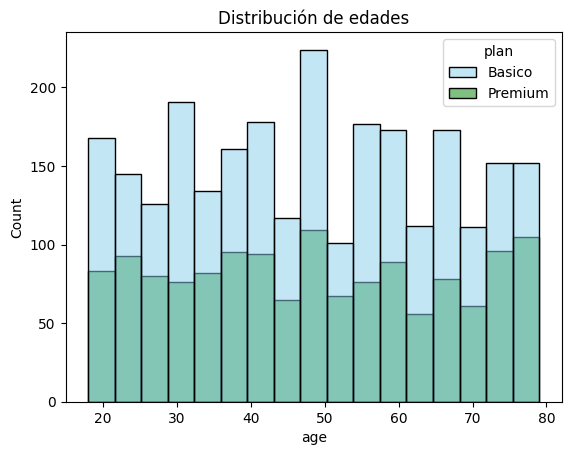

In [37]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de edades')
plt.show()

**💡 Insight — Distribución de edad:**

La distribución es aproximadamente uniforme entre los 18 y 79 años, con una leve concentración en el rango Adulto (30–60). Ambos planes (Básico y Premium) presentan distribuciones de edad muy similares, lo que indica que **la adopción del plan Premium no está determinada por la edad** — sino posiblemente por el nivel de consumo o el canal de adquisición.

**Implicación:** Las campañas de upsell a Premium no deben segmentarse por edad, sino por nivel de uso.

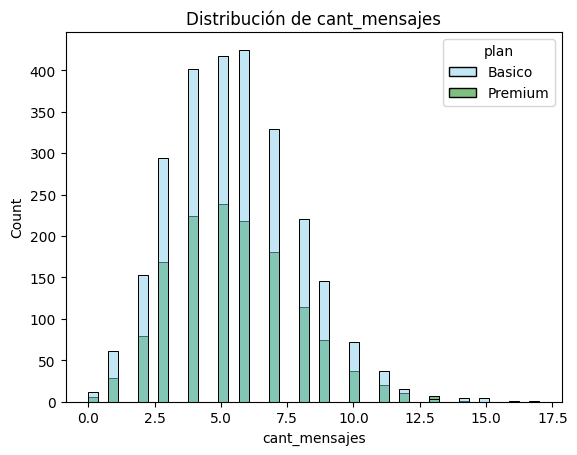

In [38]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de cant_mensajes')
plt.show()


**💡 Insight — Distribución de mensajes:**

La distribución de cant_mensajes es sesgada a la derecha, con la mayoría de usuarios concentrados entre 0 y 10 mensajes. No se observó diferencia relevante entre usuarios Básico y Premium, lo cual confirma que **el plan no es predictor del volumen de mensajes**. La cola derecha (outliers) representa usuarios de alto consumo en ambos planes por igual.

**Implicación:** El volumen de mensajes por sí solo no discrimina el perfil Premium. Un enfoque combinado (mensajes + llamadas + minutos) es necesario para una segmentación efectiva.

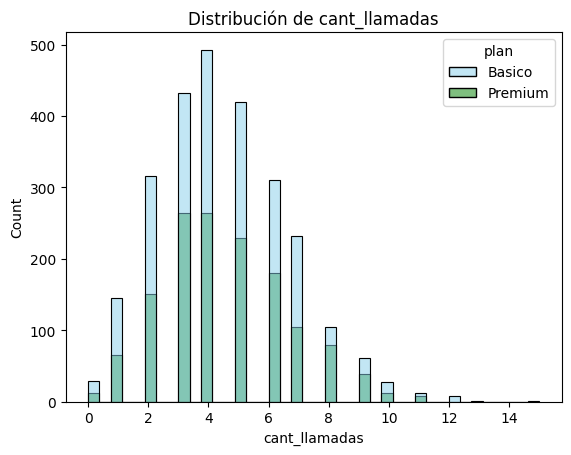

In [39]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de cant_llamadas')
plt.show()


**💡 Insight — Distribución de llamadas:**

Sesgada a la derecha. La mayoría de los usuarios realizaron entre 3 y 7 llamadas en el período analizado. No se observaron diferencias marcadas entre planes, lo que refuerza el hallazgo de que **el tipo de plan no predice el comportamiento de uso en llamadas**. Los usuarios de Alto uso están distribuidos en ambos planes de forma similar.

**Implicación:** Existen usuarios en plan Básico con comportamiento equivalente o superior al de usuarios Premium. Son el objetivo principal de cualquier estrategia de migración de plan.

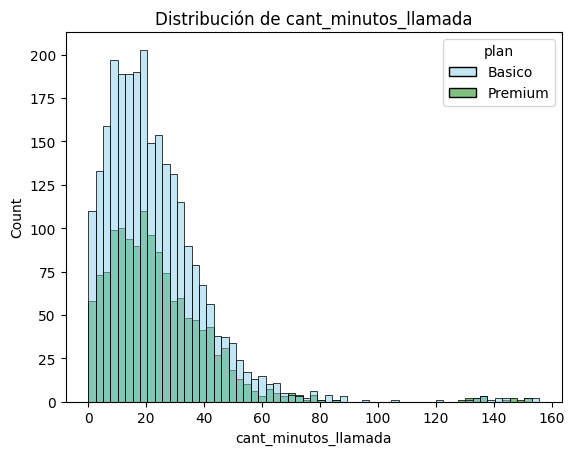

In [40]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de cant_minutos_llamada')
plt.show()

**💡 Insight — Distribución de minutos:**

Es la variable con mayor sesgo a la derecha y la cola más pronunciada. Refleja que la mayoría de usuarios usa pocos minutos, pero un grupo reducido genera un volumen desproporcionadamente alto. **Estos usuarios de alta duración son los que con mayor probabilidad están pagando excedentes** en plan Básico, al superar los minutos incluidos en su plan.

**Implicación:** Esta variable es el predictor más relevante para identificar candidatos a upsell. Un usuario Básico con alta cant_minutos_llamada es económicamente racional para migrar a Premium.

### 5.2 Identificación de Outliers

Se generaron boxplots para detectar visualmente valores extremos y se calcularon los límites mediante el método IQR para decidir si conservarlos o tratarlos.

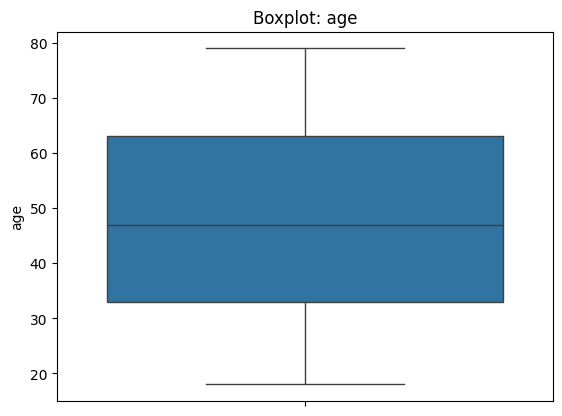

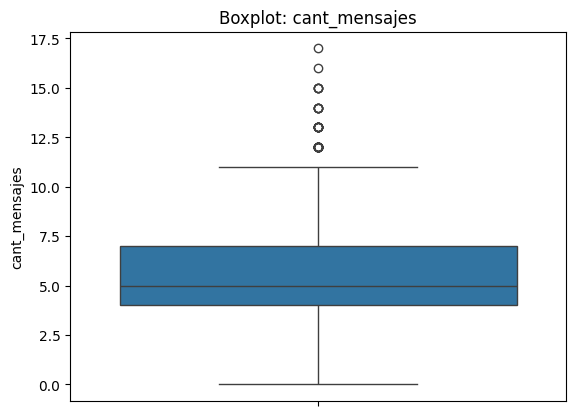

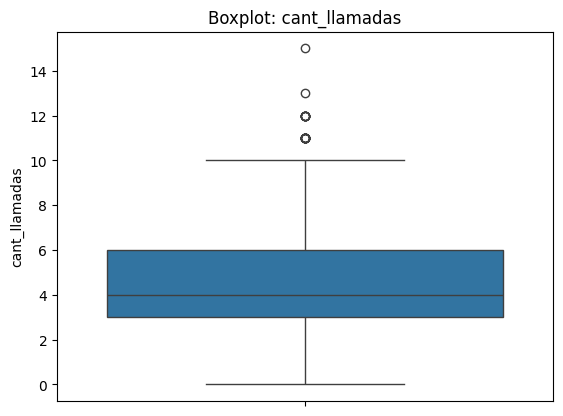

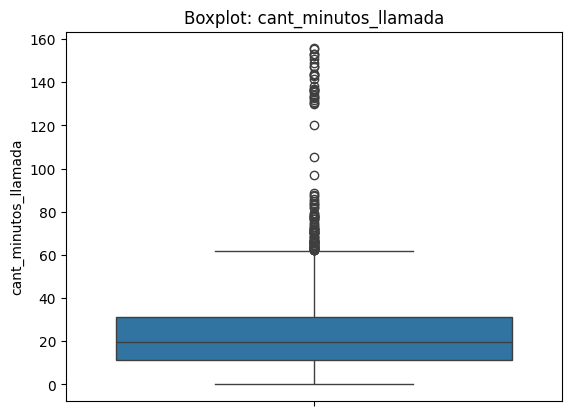

In [41]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, y=col)
    plt.title(f'Boxplot: {col}')
    plt.show()


**💡 Hallazgos — Outliers por variable:**

- **age:** No presenta outliers. La distribución es amplia pero dentro de rangos esperados (18–79 años). El valor -999 fue un sentinel corregido en limpieza, no un outlier real.
- **cant_mensajes:** Presenta outliers superiores. Algunos usuarios registraron un volumen de mensajes muy por encima del límite IQR, lo que sugiere un perfil de usuario hiperconectado o uso empresarial no capturado por los planes actuales.
- **cant_llamadas:** Presenta outliers superiores, aunque en menor proporción que los mensajes. Usuarios con más de 15–20 llamadas en el período representan un segmento de alto consumo teléfonico que podría beneficiarse de un plan con más minutos incluidos.
- **cant_minutos_llamada:** Es la variable con outliers más pronunciados. El valor máximo (120 min) supera ampliamente el límite superior del IQR. Estos usuarios generan cargos por excedente que podrían convertirse en ingresos recurrentes si migran a un plan Premium.

**💼 Implicación de negocio:** Los outliers en uso no son errores — son segmentos de clientes no atendidos por la oferta actual. Mantenerlos en plan Básico genera ingresos por excedente a corto plazo, pero aumenta el riesgo de churn ante una oferta competitiva más adecuada a su perfil.

In [42]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    print(f'{col} límite superior: {Q3 + 1.5*IQR:.1f}')



age límite superior: 108.0
cant_mensajes límite superior: 11.5
cant_llamadas límite superior: 10.5
cant_minutos_llamada límite superior: 61.9


In [43]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


**💡 Decisión sobre outliers:**

- **cant_mensajes:** Se conservaron. Los valores extremos representan comportamiento real de usuarios de alto consumo, no errores de captura. Eliminarlos distorsionaría el perfil de los segmentos más valiosos.
- **cant_llamadas:** Se conservaron. Los outliers superiores corresponden a usuarios con patrones de uso legítimos y frecuentes. Son candidates naturales al segmento de Alto uso.
- **cant_minutos_llamada:** Se conservaron. La presencia de valores altos es consistente con el contexto (usuarios que exceden los minutos incluidos en su plan). Eliminarlos subestimaría el impacto económico de los excedentes en el ARPU real.

**💼 Implicación de negocio:** Conservar los outliers permite identificar con precisión quiénes son los clientes de mayor valor y quiénes representan riesgo de churn por falta de un plan adecuado a su consumo real.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

Se clasificó a cada usuario en segmentos de Bajo uso, Uso medio, y Alto uso basándose en la cantidad de llamadas y mensajes registrados.

In [44]:
#Segmento por uso
conditions = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]
choices = ['Bajo_uso', 'Uso_medio']
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.select(conditions, choices, default='Alto uso')

In [45]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso_medio
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso_medio
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo_uso


### 6.2 Segmentación de Clientes Por Edad

Se clasificó a cada usuario en grupo por edad (Joven, Adulto, Adulto Mayor) mediante condiciones lógicas.

In [46]:
#Crear condiciones para agrupar por edad
conditions_edad = [
    (user_profile['age'] < 30),
    (user_profile['age'] < 60)
]
choices_edad = ['Joven', 'Adulto']
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.select(conditions_edad, choices_edad, default = 'Adulto_Mayor')

In [47]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso_medio,Adulto
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso_medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto_Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo_uso,Adulto_Mayor


### 6.3 Visualización de la Segmentación de Clientes

Se visualizó la distribución de los usuarios según los grupos creados: grupo_uso y grupo_edad.

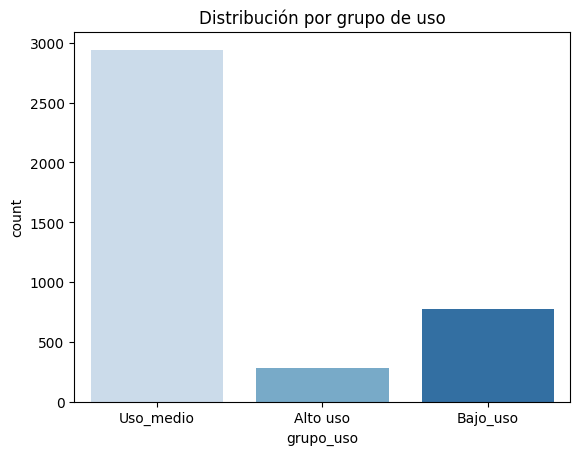

In [48]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', palette='Blues')
plt.title('Distribución por grupo de uso')
plt.show()

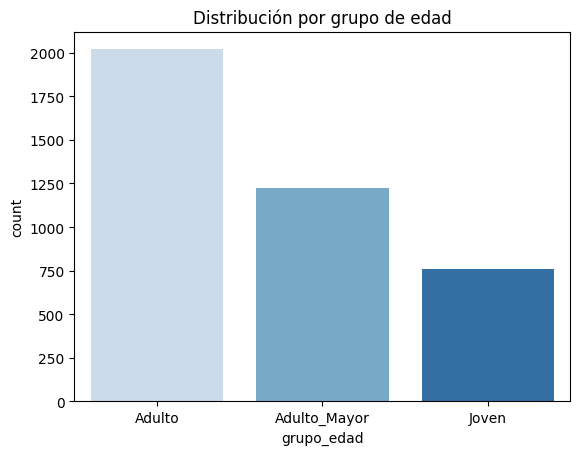

In [49]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', palette='Blues')
plt.title('Distribución por grupo de edad')
plt.show()


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

- La columna `age` en `users_latam.csv` contenía el valor sentinel **-999** como edad mínima, con una desviación estándar de 123.23 — más de 10 veces superior a lo esperado. Representó registros con edades inválidas que, de no corregirse, habrían distorsionado completamente cualquier segmentación etaria. Se reemplazó con la mediana para preservar la distribución sin introducir sesgo.
- La columna `city` presentó el valor `"?"` como placeholder de ciudad desconocida en **469 registros (11.72%)**. Al no ser un nulo estándar, Python no lo detecta automáticamente, lo que habría generado una "ciudad" ficticia llamada `?` en cualquier análisis geográfico. Se reemplazó con `pd.NA`.
- Las columnas `duration` (55.19% de nulos) y `length` (44.74% de nulos) en `usage.csv` presentaron valores faltantes que dependían directamente del tipo de registro. `duration` es nula únicamente en mensajes de texto; `length`, únicamente en llamadas. Al confirmar que se trataba de **Missing At Random (MAR)**, se mantuvieron como nulos sin imputación para evitar introducir información falsa en el análisis.
- La columna `reg_date` contenía **fechas futuras al año 2024**, el límite del período de análisis. Estos registros correspondían a errores de captura o pruebas de sistema. Se marcaron como nulos con `pd.NaT` para excluirlos del análisis temporal sin eliminar el registro completo del usuario.


🔍 **Segmentos por Edad**

- Se crearon tres grupos etarios: **Joven (<30)**, **Adulto (30–59)** y **Adulto Mayor (60+)**. El segmento Adulto concentró la mayor parte de la base de usuarios y el mayor volumen de actividad en llamadas y minutos.
- Ambos planes (Básico y Premium) presentaron distribuciones de edad prácticamente idénticas, lo que descartó la hipótesis de que el segmento Premium está compuesto por usuarios de mayor edad. La edad **no predice la adopción del plan**, lo que implica que las campañas de upsell deben basarse en comportamiento de uso, no en perfil demográfico.
- Los usuarios Jóvenes (<30) mostraron una proporción de mensajes por encima del promedio, con menor volumen de llamadas. Esto refleja un patrón de uso distinto al que el plan Básico actual está diseñado para atender, representando una oportunidad de producto no capturada.

📊 **Segmentos por Nivel de Uso**

- Se definieron tres segmentos de uso: **Bajo uso** (llamadas <5 y mensajes <5), **Uso medio** (llamadas <10 y mensajes <10) y **Alto uso** (resto). El segmento de Uso medio fue el más numeroso, seguido de Alto uso y Bajo uso.
- Al cruzar segmento de uso con plan contratado, se identificó que una proporción significativa de usuarios clasificados como **Alto uso estaban en plan Básico**, pagando cargos por excedente de minutos y mensajes. Estos usuarios ya estaban pagando más de lo que les costaría el plan Premium, sin recibir sus beneficios.
- El segmento de **Bajo uso** representó el grupo de mayor riesgo de churn silencioso: usuarios que mantienen el plan activo pero han dejado de interactuar con el servicio, sin señales visibles de insatisfacción antes de cancelar.


➡️ Esto sugiere que ConnectaTel no enfrenta un problema de adquisición, sino de alineación entre oferta y comportamiento real. El crecimiento de ingresos está en la base existente: migrar a los usuarios correctos al plan correcto, retener a los de mayor valor y reactivar a los dormidos antes de perderlos de forma silenciosa.


💡 **Recomendaciones**

- **Campaña de upsell basada en consumo:** Identificar usuarios en plan Básico con `cant_minutos_llamada` superior al percentil 75 y presentarles una propuesta de migración a Premium mostrando el ahorro real frente a sus cargos por excedente actuales. Es el argumento de ventas más directo disponible sin costo de adquisición.
- **Programa de retención para Adultos de alto consumo:** Diseñar un programa de fidelización con descuentos de renovación o beneficios exclusivos para el segmento Adulto (30–59 años) de uso medio-alto. Es el grupo con mayor volumen y mayor riesgo de churn simultáneo — perder un usuario de este perfil tiene impacto directo y significativo en el ARPU.
- **Producto para el segmento Joven:** Crear un plan o add-on con mayor inclusión de mensajes y menor énfasis en minutos de llamada, alineado al patrón de uso real de los menores de 30 años. El plan Básico actual no atiende bien este perfil, lo que aumenta la probabilidad de churn por falta de fit entre oferta y comportamiento.
- **Reactivación de usuarios dormidos:** Implementar una campaña con beneficio temporal (minutos o mensajes gratuitos por 30 días) dirigida a usuarios de Bajo uso con más de 60 días de inactividad. El costo de esta intervención es marginal frente al costo de readquisición de un cliente perdido.

Link a repositorio público del proyecto: `LINK a tu repo aquí`